In [2]:
import kagglehub
path = kagglehub.dataset_download("pranavchandane/scut-fbp5500-v2-facial-beauty-scores")

100%|██████████| 1.12G/1.12G [00:08<00:00, 145MB/s]

Extracting files...


In [4]:
import os
import kagglehub

# Ensure path is defined for this cell's execution
path = kagglehub.dataset_download("pranavchandane/scut-fbp5500-v2-facial-beauty-scores")

# List the contents of the downloaded path
print(f"Contents of the downloaded dataset at {path}:")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of the downloaded dataset at /root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2:
/root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2/labels.txt
/root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2/scut_fbp5500-cmprsd.npz
/root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2/Images
/root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2/Images/Images
/root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2/Images/Images/CF596.jpg
/root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2/Images/Images/AM946.jpg
/root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2/Images/Images/CM577.jpg
/root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-bea

In [6]:
import pandas as pd
import os

labels_file_path = os.path.join(path, 'labels.txt')

# Read the labels.txt file, assuming no header and space/tab separated values
try:
    # Use header=None to prevent the first row from being interpreted as headers
    labels_df = pd.read_csv(labels_file_path, sep=r'\s+', header=None)
    # Assign meaningful column names
    labels_df.columns = ['image_name', 'beauty_score']
    print(labels_df.head())
    print(f"\nShape of labels_df: {labels_df.shape}")
except Exception as e:
    print(f"Error reading labels.txt: {e}")
    print("Attempting to read it as a plain text file line by line to inspect content.")
    with open(labels_file_path, 'r') as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 5: # Print first 5 lines to get an idea
                break

   image_name  beauty_score
0   CF437.jpg      2.883333
1  AM1384.jpg      2.466667
2  AM1234.jpg      2.150000
3  AM1774.jpg      3.750000
4   CF215.jpg      3.033333

Shape of labels_df: (5500, 2)


In [7]:
image_dir = os.path.join(path, 'Images', 'Images') # Adjust if structure is different

# Create a new column 'image_path' with the full path to each image
labels_df['image_path'] = labels_df['image_name'].apply(lambda x: os.path.join(image_dir, x))

# Verify that all image paths exist
missing_images = labels_df[~labels_df['image_path'].apply(os.path.exists)]

if not missing_images.empty:
    print(f"Warning: {len(missing_images)} images are listed in labels.txt but not found in the image directory.")
    print(missing_images.head())
else:
    print("All images listed in labels.txt have corresponding files in the image directory.")

print("\nDataFrame with image paths:")
print(labels_df.head())

All images listed in labels.txt have corresponding files in the image directory.

DataFrame with image paths:
   image_name  beauty_score                                         image_path
0   CF437.jpg      2.883333  /root/.cache/kagglehub/datasets/pranavchandane...
1  AM1384.jpg      2.466667  /root/.cache/kagglehub/datasets/pranavchandane...
2  AM1234.jpg      2.150000  /root/.cache/kagglehub/datasets/pranavchandane...
3  AM1774.jpg      3.750000  /root/.cache/kagglehub/datasets/pranavchandane...
4   CF215.jpg      3.033333  /root/.cache/kagglehub/datasets/pranavchandane...


In [8]:
from sklearn.model_selection import train_test_split

# Split the dataset into training, validation, and test sets
# We'll use 70% for training, 15% for validation, and 15% for testing

train_df, temp_df = train_test_split(labels_df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

print("\nFirst 5 rows of Training DataFrame:")
print(train_df.head())

Training set size: 3850
Validation set size: 825
Test set size: 825

First 5 rows of Training DataFrame:
      image_name  beauty_score  \
5409    CM20.jpg      3.966667   
2910  AF1602.jpg      3.700000   
4019   CF685.jpg      3.466667   
2119   CF652.jpg      3.950000   
2244   AM717.jpg      2.133333   

                                             image_path  
5409  /root/.cache/kagglehub/datasets/pranavchandane...  
2910  /root/.cache/kagglehub/datasets/pranavchandane...  
4019  /root/.cache/kagglehub/datasets/pranavchandane...  
2119  /root/.cache/kagglehub/datasets/pranavchandane...  
2244  /root/.cache/kagglehub/datasets/pranavchandane...  


In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1]
    rotation_range=20,       # Randomly rotate images by 20 degrees
    width_shift_range=0.2,   # Randomly shift images horizontally
    height_shift_range=0.2,  # Randomly shift images vertically
    shear_range=0.2,         # Apply random shearing transformations
    zoom_range=0.2,          # Apply random zoom transformations
    horizontal_flip=True,    # Randomly flip images horizontally
    fill_mode='nearest'      # Fill newly created pixels with the nearest available value
)

# Preprocessing for validation and test data (only rescaling)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='beauty_score',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='raw', # For regression tasks, use 'raw'
    shuffle=True
)

val_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='beauty_score',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='raw', # For regression tasks, use 'raw'
    shuffle=False # No need to shuffle validation data
)

test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='beauty_score',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='raw', # For regression tasks, use 'raw'
    shuffle=False # No need to shuffle test data
)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Found 3850 validated image filenames.
Found 825 validated image filenames.
Found 825 validated image filenames.


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the MobileNetV2 model pre-trained on ImageNet data, excluding the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the layers of the base model so they are not updated during initial training
for layer in base_model.layers:
    layer.trainable = False

# Add a custom head for our regression task
x = base_model.output
x = GlobalAveragePooling2D()(x) # Global Average Pooling to reduce dimensions
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # Dropout for regularization to prevent overfitting
predictions = Dense(1, activation='linear')(x) # Output layer with a single neuron for regression

# Create the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model for regression
# Using Adam optimizer and Mean Squared Error (MSE) as loss for regression
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
# ModelCheckpoint saves the best model based on validation MAE
checkpoint = ModelCheckpoint(
    'best_beauty_predictor_model.keras', # .keras extension for Keras v3+ serialization
    monitor='val_mae',
    save_best_only=True,
    mode='min',
    verbose=1
)

# EarlyStopping stops training if validation MAE does not improve for 'patience' epochs
early_stopping = EarlyStopping(
    monitor='val_mae',
    patience=10,
    mode='min',
    verbose=1,
    restore_best_weights=True
)

callbacks = [checkpoint, early_stopping]

# Train the model
history = model.fit(
    train_generator,
    epochs=1, # You can adjust the number of epochs
    validation_data=val_generator,
    callbacks=callbacks
)

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - loss: 0.7284 - mae: 0.6758
Epoch 1: val_mae improved from None to 0.40225, saving model to best_beauty_predictor_model.keras

Epoch 1: finished saving model to best_beauty_predictor_model.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 105s 866ms/step - loss: 0.6681 - mae: 0.6466 - val_loss: 0.2595 - val_mae: 0.4022
Restoring model weights from the end of the best epoch: 1.


After training, we will evaluate the model's performance on the test set and then create an interface for predictions.

In [16]:
# Evaluate the model on the test set
loss, mae = model.evaluate(test_generator)
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 644ms/step - loss: 0.2810 - mae: 0.4077
Test Loss (MSE): 0.2810
Test MAE: 0.4077


Now that the model is trained and evaluated, let's visualize the training history (loss and MAE) and then prepare an interface for making predictions on new images.

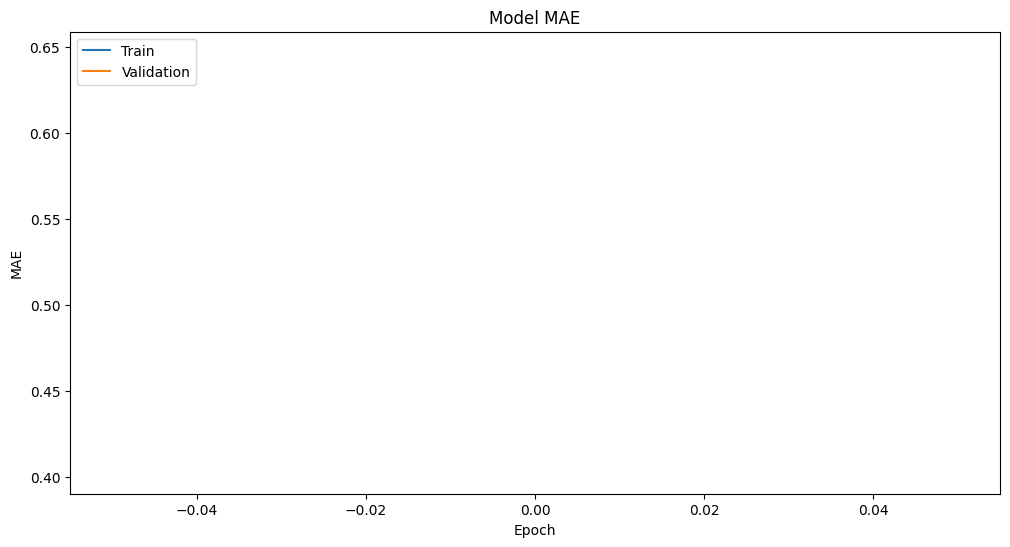

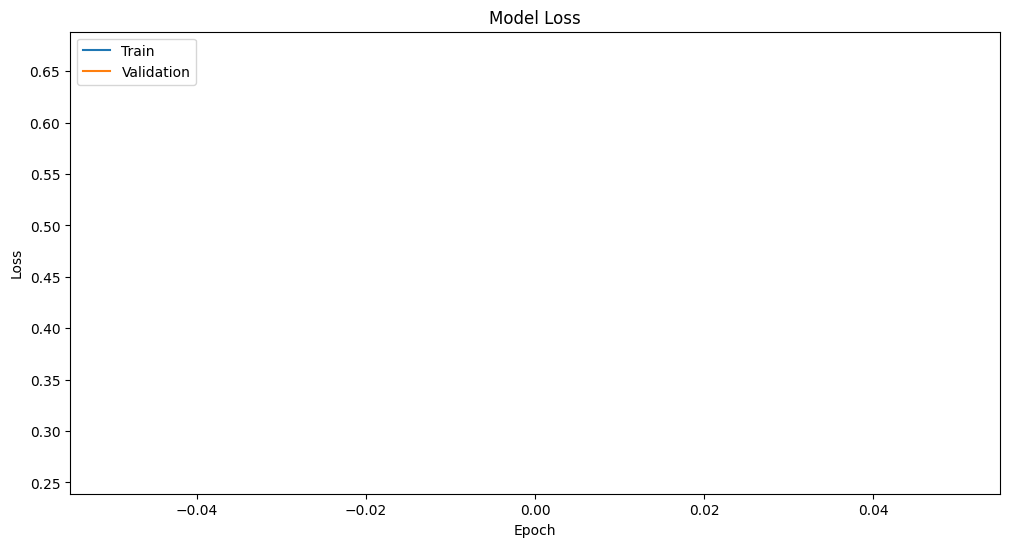

In [17]:
import matplotlib.pyplot as plt

# Plot training & validation MAE values
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Now, let's create a Streamlit app to interact with the model. You'll need to install `streamlit` first.

In [18]:
!pip install streamlit numpy Pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 135.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 25.0.0
    Uninstalling pyarrow-25.0.0:
      Successfully uninstalled pyarrow-25.0.0
  Attempting uninstall: blinker
    Found existing installation: blinker 1.4
error: uninstall-distutils-installed-package

× Cannot uninstall blinker 1.4
╰─> It is a distutils installed project and thus we cannot accurately determine which files belong to it which would lead to only a partial uninstall.


After installing the necessary libraries, you can run the following code to create a Streamlit app. Please note that Streamlit apps typically run in a separate process and might require a bit of setup in a Colab environment to display properly (e.g., using `ngrok` or `localtunnel`). For a quick local interaction within Colab, we can use `streamlit run app.py` in a shell, but for a more integrated experience, this code provides the application logic.

In [35]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import os
import time

# Define image dimensions (must match what the model was trained on)
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Set page configuration for a wider layout and title
st.set_page_config(layout="centered", page_title="Facial Beauty Predictor")

# Load the trained model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('best_beauty_predictor_model.keras')
    return model

model = load_model()

st.header('✨ Facial Beauty Score Predictor ✨', divider='rainbow')
st.subheader('Upload an image and let our deep learning model estimate its beauty score.')

# Sidebar for information
st.sidebar.header('About the App')
st.sidebar.info(
    "This application uses a deep learning model (MobileNetV2 with a custom regression head) "
    "to predict a 'beauty score' for uploaded facial images. "
    "The model was trained on the SCUT-FBP5500 dataset, where scores typically range from 1 to 5."
)
st.sidebar.caption('Developed with Streamlit and TensorFlow')

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file).convert('RGB')

    col1, col2 = st.columns([1, 1])

    with col1:
        st.image(image, caption='Uploaded Image') # Removed use_column_width=True

    with col2:
        st.write("### Analyzing Image...")
        # Add a spinner while predicting
        with st.spinner('Predicting beauty score...'):
            # Preprocess the image for the model
            img_array = np.array(image.resize((IMG_WIDTH, IMG_HEIGHT)))
            img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
            img_array = img_array / 255.0 # Normalize pixel values

            # Make prediction
            prediction = model.predict(img_array)[0][0]
            time.sleep(1) # Simulate a short delay for better UX

        st.markdown("--- ")
        st.metric(label="Predicted Beauty Score", value=f"{prediction:.2f}")

        st.write(
            "**Interpretation:** This score is an estimate based on the model's training data. "
            "Scores are typically on a scale from 1 (least attractive) to 5 (most attractive)."
        )

else:
    st.info('Please upload an image file to get a beauty score prediction. Supported formats: JPG, JPEG, PNG.')
    st.image('https://via.placeholder.com/600x400?text=Upload+Image+Here', caption='Placeholder Image')


Overwriting app.py


In [21]:
!pip install --ignore-installed blinker
!pip install streamlit

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
  Using cached streamlit-1.61.1-py3-none-any.whl.metadata (10 kB)
  Using cached pydeck-0.9.3-py2.py3-none-any.whl.metadata (4.2 kB)
Using cached streamlit-1.61.1-py3-none-any.whl (10.5 MB)
Using cached pydeck-0.9.3-py2.py3-none-any.whl (11.4 MB)


In [22]:
!pip install streamlit pyngrok

In [23]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [41]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [42]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &




2026-08-11 14:20:13.550 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.67.83.224:8501

I0000 00:00:1786458017.107671    9381 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
I0000 00:00:1786458018.612745    9381 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1786458019.971080    9381 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNK

To run the Streamlit app, you would typically execute `!streamlit run app.py` in a new cell. In Colab, you might need to expose the port. Here's how you can do it using `localtunnel` for demonstration purposes. **Please be aware of the security implications when exposing ports and only do so for trusted applications.**

In [20]:
!npm install -g localtunnel
!nohup streamlit run app.py --server.port 8080 &>/dev/null &
!lt --port 8080

⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 1s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.2
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.2
npm notice To update run: npm install -g npm@12.0.2
npm notice
⠏your url is: https://smooth-eyes-look.loca.lt
^C


This code defines a deep learning model using transfer learning with MobileNetV2. The pre-trained layers are frozen, and a custom regression head is added. The model is compiled with the Adam optimizer and Mean Squared Error loss, suitable for predicting continuous beauty scores. Next, we will train this model using our data generators.

In [11]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 778.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 96.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


TensorFlow should now be installed. After this cell executes, please re-run the cell above (the one defining `train_generator`, `val_generator`, and `test_generator`) to ensure the data generators are created successfully.

With the data generators set up, we are now ready to define and compile our deep learning model architecture. We will then train the model using these generators.

Now that our data is split, we're ready to define and build our deep learning model. We'll typically use the training set to train the model, the validation set to monitor performance during training and tune hyperparameters, and the test set for a final, unbiased evaluation of the model.

With the image paths now correctly added to the DataFrame, we have a complete dataset ready for further preprocessing and model training. The next step will involve defining our deep learning model architecture and preparing the images and labels for input.

This will help us understand the format of the beauty scores and how they are linked to the image filenames. Once we have this, we can proceed with data loading and preparation for our deep learning model.

This output will help us identify where the images and any associated metadata (like beauty scores) are located within the dataset. Once we know the structure, we can proceed with data loading and preprocessing for the deep learning model.